In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [73]:
file_path = "gym_recommendation.csv"
df = pd.read_csv(file_path)

In [74]:
df.head()

,ID,Sex,Age,Height,Weight,Hypertension,Diabetes,BMI,Level,Fitness Goal,Fitness Type,Exercises,Equipment,Diet,Recommendation
0,1,Male,18,1.68,47.5,No,No,16.83,Underweight,Weight Gain,Muscular Fitness,"Squats, deadlifts, bench presses, and overhead...",Dumbbells and barbells,"Vegetables: (Carrots, Sweet Potato, and Lettuc...",Follow a regular exercise schedule. Adhere to ...
1,2,Male,18,1.68,47.5,Yes,No,16.83,Underweight,Weight Gain,Muscular Fitness,"Squats, deadlifts, bench presses, and overhead...","Light athletic shoes, resistance bands, and li...","Vegetables: (Tomatoes, Garlic, leafy greens, b...",Follow a regular exercise schedule. Adhere to ...
2,3,Male,18,1.68,47.5,No,Yes,16.83,Underweight,Weight Gain,Muscular Fitness,"Squats, yoga, deadlifts, bench presses, and ov...","Dumbbells, barbells and Blood glucose monitor","Vegetables: (Garlic, Roma Tomatoes, Capers and...",Follow a regular exercise schedule. Adhere to ...
3,4,Male,18,1.68,47.5,Yes,Yes,16.83,Underweight,Weight Gain,Muscular Fitness,"Squats, yoga, deadlifts, bench presses, and ov...","Light athletic shoes, resistance bands, light ...","Vegetables: (Garlic, Roma Tomatoes, Capers, Gr...",Follow a regular exercise schedule. Adhere to ...
4,5,Male,18,1.68,47.5,No,No,16.83,Underweight,Weight Gain,Muscular Fitness,"Squats, deadlifts, bench presses, and overhead...",Dumbbells and barbells,"Vegetables: (Carrots, Sweet Potato, Lettuce); ...",Follow a regular exercise schedule. Adhere to ...


In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14589 entries, 0 to 14588
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              14589 non-null  int64  
 1   Sex             14589 non-null  object 
 2   Age             14589 non-null  int64  
 3   Height          14589 non-null  float64
 4   Weight          14589 non-null  float64
 5   Hypertension    14589 non-null  object 
 6   Diabetes        14589 non-null  object 
 7   BMI             14589 non-null  float64
 8   Level           14589 non-null  object 
 9   Fitness Goal    14589 non-null  object 
 10  Fitness Type    14589 non-null  object 
 11  Exercises       14589 non-null  object 
 12  Equipment       14589 non-null  object 
 13  Diet            14589 non-null  object 
 14  Recommendation  14589 non-null  object 
dtypes: float64(3), int64(2), object(10)
memory usage: 1.7+ MB


C:\Users\HP\AppData\Local\Temp\ipykernel_16120\2979756217.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['Level'], palette='viridis')


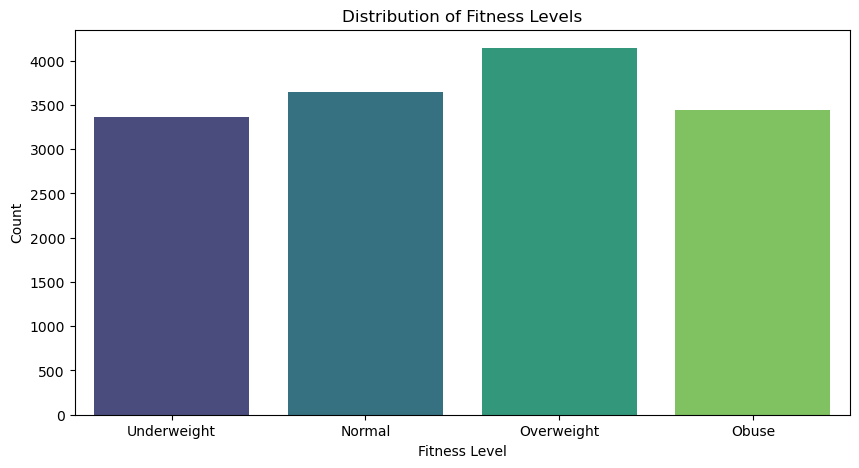

In [79]:
plt.figure(figsize=(10, 5))
sns.countplot(x=df['Level'], palette='viridis')
plt.title("Distribution of Fitness Levels")
plt.xlabel("Fitness Level")
plt.ylabel("Count")
plt.show()

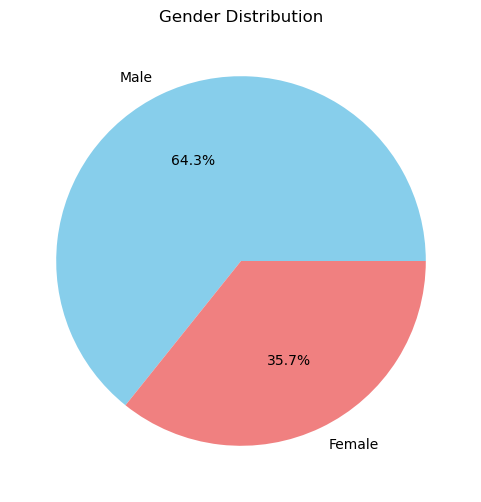

In [80]:
plt.figure(figsize=(6, 6))
df['Sex'].value_counts().plot.pie(autopct='%1.1f%%', colors=['skyblue', 'lightcoral'])
plt.title("Gender Distribution")
plt.ylabel("")
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_16120\2983127134.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['Fitness Goal'], palette='coolwarm')


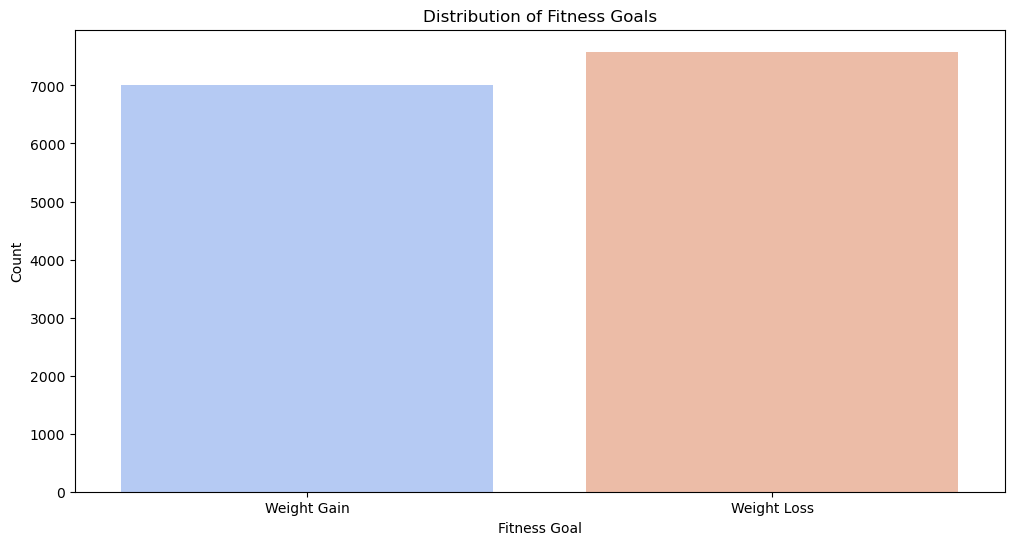

In [81]:
plt.figure(figsize=(12, 6))
sns.countplot(x=df['Fitness Goal'], palette='coolwarm')
plt.title("Distribution of Fitness Goals")
plt.xlabel("Fitness Goal")
plt.ylabel("Count")
plt.show()

In [82]:
label_encoders = {col: LabelEncoder().fit(df[col]) for col in ['Sex', 'Level', 'Fitness Goal', 'Fitness Type','Exercises','Equipment','Diet','Recommendation','Hypertension','Diabetes']}
for col, le in label_encoders.items():
    df[col] = le.transform(df[col])
df

,ID,Sex,Age,Height,Weight,Hypertension,Diabetes,BMI,Level,Fitness Goal,Fitness Type,Exercises,Equipment,Diet,Recommendation
0,1,1,18,1.68,47.5,0,0,16.83,3,0,1,1,0,3,6
1,2,1,18,1.68,47.5,1,0,16.83,3,0,1,1,7,10,5
2,3,1,18,1.68,47.5,0,1,16.83,3,0,1,2,1,5,3
3,4,1,18,1.68,47.5,1,1,16.83,3,0,1,2,8,6,1
4,5,1,18,1.68,47.5,0,0,16.83,3,0,1,1,0,2,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14584,14585,1,35,1.88,98.0,0,0,27.73,2,1,0,0,3,1,7
14585,14586,1,36,1.89,99.0,0,0,27.71,2,1,0,0,3,1,7
14586,14587,1,37,1.90,100.0,0,0,27.70,2,1,0,0,3,1,7
14587,14588,1,38,1.91,101.0,0,0,27.69,2,1,0,0,3,1,7


In [84]:
x = df.drop(columns=['ID', 'Fitness Type', 'Exercises', 'Equipment', 'Diet', 'Recommendation'])
y = df[[ 'Fitness Type', 'Exercises', 'Equipment', 'Diet', 'Recommendation']]
x

,Sex,Age,Height,Weight,Hypertension,Diabetes,BMI,Level,Fitness Goal
0,1,18,1.68,47.5,0,0,16.83,3,0
1,1,18,1.68,47.5,1,0,16.83,3,0
2,1,18,1.68,47.5,0,1,16.83,3,0
3,1,18,1.68,47.5,1,1,16.83,3,0
4,1,18,1.68,47.5,0,0,16.83,3,0
...,...,...,...,...,...,...,...,...,...
14584,1,35,1.88,98.0,0,0,27.73,2,1
14585,1,36,1.89,99.0,0,0,27.71,2,1
14586,1,37,1.90,100.0,0,0,27.70,2,1
14587,1,38,1.91,101.0,0,0,27.69,2,1


In [86]:
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.2, random_state=42)
x_train

,Sex,Age,Height,Weight,Hypertension,Diabetes,BMI,Level,Fitness Goal
13082,1,50,1.76,94.0,1,1,30.35,1,1
5502,0,37,1.84,105.0,1,0,31.01,1,1
1570,1,26,1.65,47.5,0,1,17.45,3,0
9159,0,43,1.79,40.0,1,1,12.48,3,0
9581,1,56,1.55,59.0,1,0,24.56,0,0
...,...,...,...,...,...,...,...,...,...
5191,0,28,1.75,50.0,0,1,16.33,3,0
13418,1,61,1.88,67.0,1,1,18.96,0,0
5390,0,34,1.81,70.0,1,0,21.37,0,0
860,0,44,1.68,86.0,0,0,30.47,1,1


In [87]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
multi_output_clf = MultiOutputClassifier(rf)
multi_output_clf.fit(x_train, y_train)

MultiOutputClassifier(estimator=RandomForestClassifier(random_state=42))

In [88]:
y_pred = multi_output_clf.predict(x_test)

In [91]:
for i, col in enumerate(y.columns):
    print(f"Accuracy for {col}: {accuracy_score(y_test[col], y_pred[:, i])}")
    print(classification_report(y_test[col], y_pred[:, i]))

Accuracy for Fitness Type: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1479
           1       1.00      1.00      1.00      1439

    accuracy                           1.00      2918
   macro avg       1.00      1.00      1.00      2918
weighted avg       1.00      1.00      1.00      2918

Accuracy for Exercises: 0.997943797121316
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       774
           1       1.00      0.99      1.00       716
           2       1.00      1.00      1.00       725
           3       1.00      0.99      1.00       370
           4       0.99      1.00      1.00       333

    accuracy                           1.00      2918
   macro avg       1.00      1.00      1.00      2918
weighted avg       1.00      1.00      1.00      2918

Accuracy for Equipment: 0.95407813570939
              precision    recall  f1-score   support

           0   

In [94]:
def check_overfitting(model, x_train, y_train, x_test, y_test):
    train_scores = []
    test_scores = []

    for i, col in enumerate(y_train.columns):
        # train prediction
        y_train_pred = model.predict(x_train)[:, i]
        train_acc = accuracy_score(y_train[col], y_train_pred)
        train_scores.append(train_acc)

        # test prediction
        y_test_pred = model.predict(x_test)[:, i]
        test_acc = accuracy_score(y_test[col], y_test_pred)
        test_scores.append(test_acc)

        print(f"Feature: {col}")
        print(f" Train Accuracy: {train_acc:.4f}")
        print(f" Test Accuracy: {test_acc:.4f}")
        print(f"Overfitting Gap: {train_acc - test_acc:.4f}")
        print("---------------")
    
    avg_gap = np.mean(np.array(train_scores) - np.array(test_scores))
    print(f"\n📊 Average Overfitting Gap across all outputs: {avg_gap:.4f}")


In [95]:
check_overfitting(multi_output_clf, x_train, y_train, x_test, y_test)

Feature: Fitness Type
 Train Accuracy: 1.0000
 Test Accuracy: 1.0000
Overfitting Gap: 0.0000
---------------
Feature: Exercises
 Train Accuracy: 1.0000
 Test Accuracy: 0.9979
Overfitting Gap: 0.0021
---------------
Feature: Equipment
 Train Accuracy: 0.9991
 Test Accuracy: 0.9541
Overfitting Gap: 0.0451
---------------
Feature: Diet
 Train Accuracy: 0.9941
 Test Accuracy: 0.9503
Overfitting Gap: 0.0438
---------------
Feature: Recommendation
 Train Accuracy: 0.9998
 Test Accuracy: 0.9578
Overfitting Gap: 0.0420
---------------

📊 Average Overfitting Gap across all outputs: 0.0266


In [96]:
def calculate_bmi(weight, height):
    
    return weight / (height ** 2)

weight = 70  
height = 1.75 

bmi = calculate_bmi(weight, height)
print(f"BMI: {bmi:.2f}")

BMI: 22.86


In [97]:
def calculate_fitness_level(bmi):
    
    if bmi < 18.5:
        return 'Underweight'
    elif 18.5 <= bmi <= 24.9:
        return 'Normal weight'
    elif 25 <= bmi <= 29.9:
        return 'Overweight'
    else:
        return 'Obesity'

level= calculate_fitness_level(22.86)
print(f'levelL {level}')

levelL Normal weight


In [98]:
new_data = pd.DataFrame([{
    'Sex': label_encoders['Sex'].transform(['Male'])[0],
    'Age': 30,
    'Height': 1.70,
    'Weight': 78,
    'Hypertension': label_encoders['Hypertension'].transform(['No'])[0],
    'Diabetes': label_encoders['Diabetes'].transform(['No'])[0],
    'BMI': round(78 / (1.70**2), 2),  
    'Level': label_encoders['Level'].transform(['Overweight'])[0],
    'Fitness Goal': label_encoders['Fitness Goal'].transform(['Weight Loss'])[0]
}])


prediction = multi_output_clf.predict(new_data)

output = {}
for i, col in enumerate(y.columns):
    output[col] = label_encoders[col].inverse_transform([prediction[0][i]])[0]

print("🎯 Recommended Plan:")
for key, value in output.items():
    print(f"{key}: {value}")


🎯 Recommended Plan:
Fitness Type: Cardio Fitness
Exercises: Brisk walking, cycling, swimming, running , or dancing.
Equipment: Ellipticals, Indoor Rowers,Treadmills, and Rowing machine
Diet: Vegetables: (Broccoli, Carrots, Spinach, Lettuce, Onion); Protein Intake: (Cheese, Cattoge cheese, Skim Milk, Law fat Milk, and Baru Nuts); Juice: (Fruit Juice, Aloe vera juice, Cold-pressed juice, and Watermelon juice)
Recommendation: Follow a regular exercise schedule. Adhere to the exercise and diet plan to get better results. It is important to approach weight loss in a healthy and balanced way, focusing on exercise and nutrition. Keep in mind that weight loss should be gradual and focused on building lean muscle rather than increasing fat. Additionally, it's always a good idea to consult with a healthcare professional or registered dietitian before making any significant changes to your exercise or diet plan. Here are some important tips:- Stay hydrated by drinking enough water throughout the 